# Feature Scaling: The Level Playing Field ⚖️

In Machine Learning, models are just math engines. Without feature scaling, your datasets suffer from **Feature Domination**, where columns with large numbers (like Salary) "cheat" and beat smaller columns (like Number of Children) simply because their numbers are bigger.

---

## 🧠 The Problem
Imagine a model predicting house prices:
1. **Salary**: $40,000 to $500,000
2. **Number of Children**: 0 to 5

A 1-unit change in Salary (+$1) is mathematically the same to a computer as a 1-unit change in Children (+1 child). But in the real world, the child is far more significant. Scaling fixes this.

---

## 🛠️ The Two Main Solutions

### 1. Normalization (Min-Max Scaling)
Shifts and squashes everything into a range between **0 and 1**.
- **Math**: `(x - Min) / (Max - Min)`
- **When to use**: When you don't know the distribution or it's NOT a bell curve.

### 2. Standardization (Z-Score Scaling)
Centers data around **0** with a Standard Deviation of **1**.
- **Math**: `(x - μ) / σ`
- **When to use**: When your data follows a **Normal Distribution** (Bell Curve). This is the standard choice for SVM, K-Means, and Neural Networks.

---

## 🎨 Visualization Table

| Feature | Raw Data | Normalized (0 to 1) | Standardized (Z-score) |
| :--- | :--- | :--- | :--- |
| **Salary** | $100,000 | 0.25 | -1.2 |
| **Children** | 4 | 0.80 | 1.5 |

By scaling, the model can now see that having 4 children is a more "significant" value relative to its column than $100k is to its own.

---

## 🧠 Why we scale:
1. **Prevents Domination**: Ensures $500,000 doesn't automatically beat a 5.
2. **Speed**: Optimization algorithms (like Gradient Descent) finish faster.
3. **Logic**: Required by distance-based algorithms like KNN or K-Means.

> [!NOTE]
> Always fit your scalers on the **Training Set** and only transform the **Test Set** to avoid data leakage!


### Test

In [96]:
print("hello world")

hello world


### Importing Libs & data

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
dataset = pd.read_csv("../data/messy_ml_data.csv")
dataset.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


# Should outliers be removed and missing values be filled before feature scaling?
# The ML Pipeline: Order of Operations 🏆

A common question in data science is: **"Does the order of cleaning matter?"** The answer is **Yes.** Following the wrong order can result in biased models or code errors.

---

## 📅 The Ideal Pipeline
1.  **Imputation** (Fill Missing Values)
2.  **Outlier Handling** (Capping or Removing)
3.  **Feature Scaling** (Standardization/Normalization)

---

## 🧠 Why This Order?

### 1. Why Impute First?
Most Scaling algorithms (like `StandardScaler` or `MinMaxScaler`) are purely mathematical. They **cannot handle `NaN` values**. If you try to calculate a Mean or a Range while there are nulls, the computer will crash or return an error. You must have a complete set of numbers first.

### 2. Why Handle Outliers Before Scaling?
Scaling is **extremely sensitive** to extreme values.

*   **Normalization Trap**: If you have an Age column with `[20, 30, 40]` and one outlier of `200`, the 200 becomes the **1.0**. This "squashes" the 20, 30, and 40 into a tiny, indistinguishable range (e.g., `0.10, 0.15, 0.20`). Your model loses its ability to see the differences between normal people.
*   **Standardization Trap**: Outliers pull the **Mean ($\mu$)** and **Standard Deviation ($\sigma$)** toward them. This creates a "distorted" center, making the scaling inaccurate for the 99% of your "normal" data.

---

## ⚖️ The Exception: Robust Scaling
If you absolutely **cannot** remove your outliers (e.g., they represent valid but rare events), use the **`RobustScaler`** in Scikit-Learn.
- It uses the **Median** and **IQR** instead of Mean and Std Dev.
- It is designed to scale your data while "ignoring" the mathematical blast radius of the outliers.

---

## 🧪 Summary Table

| Step | Action | Why? |
| :--- | :--- | :--- |
| **1. Impute** | Fill NaNs | Scalers need complete numerical arrays to work. |
| **2. Outliers** | Remove/Cap | Prevents the scaled range from getting "distorted." |
| **3. Scaling** | Scale | Final step to prepare data for the ML model. |


### Handling Missing values

In [99]:
dataset.isnull().sum()

PassengerId       0
Age              16
Fare             25
Gender           23
City             21
Subscription     26
Score            16
JoinDate         20
Email            12
Phone            26
IsActive         21
Remarks          26
DeptCode         21
DiscountCode    462
dtype: int64

In [100]:
# 1. Fill Age with Median (Robust against the 200-year-olds)
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
# 2. Fill Fare with Median (Robust against expensive outliers)
dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].median())
# 3. Fill Score with Median (Standard Safe choice)
dataset['Score'] = dataset['Score'].fillna(dataset['Score'].median())
# 4. Verify all nulls are gone
print(dataset[['Age', 'Fare', 'Score']].isnull().sum())

Age      0
Fare     0
Score    0
dtype: int64


### Removing outliers

<Axes: xlabel='Fare'>

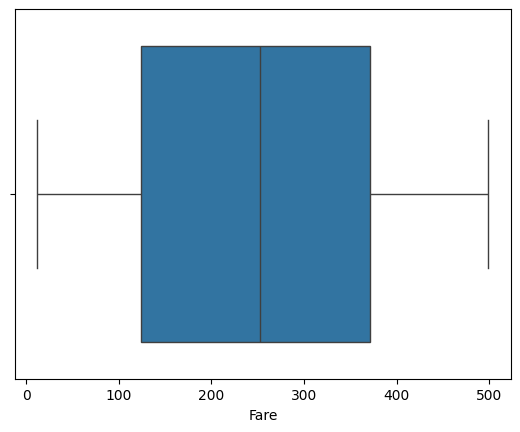

In [101]:
sns.boxplot(x='Fare', data=dataset)

<Axes: xlabel='Age'>

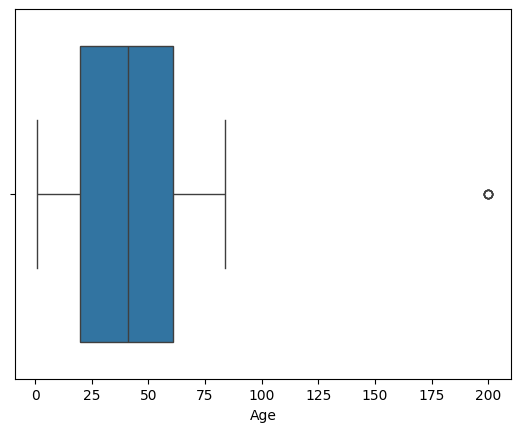

In [102]:
sns.boxplot(x='Age', data=dataset)

<Axes: xlabel='Score'>

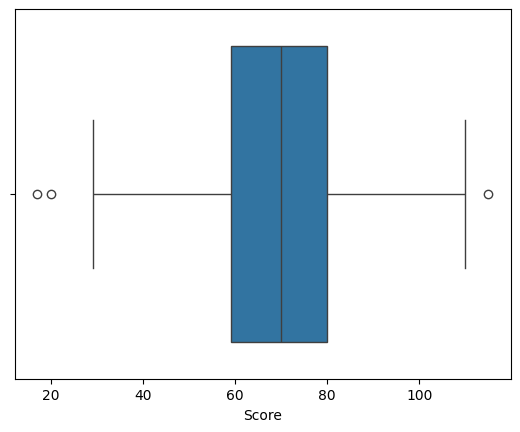

In [103]:
sns.boxplot(x='Score', data=dataset)

In [104]:
# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the DataFrame
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [105]:
# Apply to each column sequentially
dataset_clean = remove_outliers(dataset, 'Age')
dataset_clean = remove_outliers(dataset_clean, 'Fare')
dataset_clean = remove_outliers(dataset_clean, 'Score')
# 4. Verify the results
print(f"Original Dataset Size: {len(dataset)}")
print(f"Cleaned Dataset Size: {len(dataset_clean)}")
print(f"Total Rows Removed: {len(dataset) - len(dataset_clean)}")

Original Dataset Size: 761
Cleaned Dataset Size: 753
Total Rows Removed: 8


<Axes: xlabel='Age'>

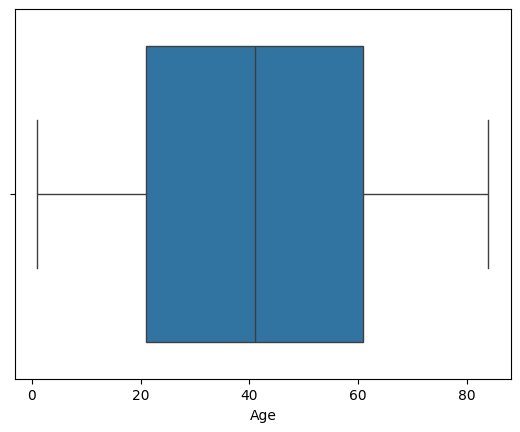

In [106]:
sns.boxplot(x='Age', data=dataset_clean)

<Axes: xlabel='Fare'>

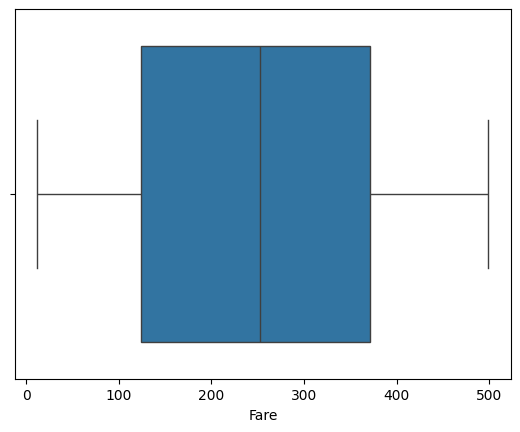

In [107]:
sns.boxplot(x='Fare', data=dataset_clean)

<Axes: xlabel='Score'>

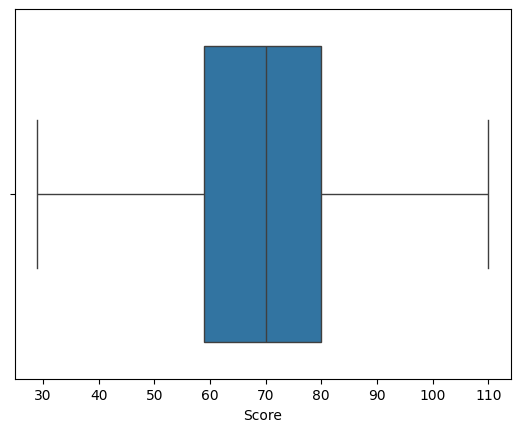

In [108]:
sns.boxplot(x='Score', data=dataset_clean)

# Feature scaling for Age, Score and Fare columns

## Standardization

In [109]:
from sklearn.preprocessing import StandardScaler

In [110]:
# 1. Initialize the Scaler
scaler = StandardScaler()

In [111]:
# 2. Select the columns to scale 
# (Use the 'dataset_clean' we created after outlier removal)
cols_to_scale = ['Age', 'Fare', 'Score']

In [112]:
# 3. Fit and Transform the data
# This calculates the Mean/Std and applies the (x - mu) / sigma math
scaled_data = scaler.fit_transform(dataset_clean[cols_to_scale])
scaled_data

array([[ 0.47137899, -1.05113262, -1.01219371],
       [-1.10408767, -1.57951844,  0.89132218],
       [ 1.32298259, -1.13260902,  1.45532689],
       ...,
       [-1.35956875,  0.48851485, -0.80069195],
       [ 0.42879881, -0.16080359, -0.58919018],
       [-0.93376695,  0.60930503, -0.73019136]], shape=(753, 3))

In [113]:
# 4. Convert the resulting array back to a DataFrame for easier viewing
cols_scaled = ['Age_ss', 'Fare_ss', 'Score_ss']
scaled_df = pd.DataFrame(scaled_data, columns=cols_scaled)
scaled_df

,Age_ss,Fare_ss,Score_ss
0,0.471379,-1.051133,-1.012194
1,-1.104088,-1.579518,0.891322
2,1.322983,-1.132609,1.455327
3,0.854601,-0.749941,1.243825
4,-0.848607,-1.104406,0.256817
...,...,...,...
748,0.812020,-1.311230,0.045315
749,0.684280,1.417161,0.891322
750,-1.359569,0.488515,-0.800692
751,0.428799,-0.160804,-0.589190


In [114]:
# 📊 Verification: Mean should be ~0 and Std Dev should be ~1
print("\nMean of scaled columns:")
print(scaled_df.mean().round(2))
print("\nStandard Deviation of scaled columns:")
print(scaled_df.std().round(2))


Mean of scaled columns:
Age_ss     -0.0
Fare_ss     0.0
Score_ss    0.0
dtype: float64

Standard Deviation of scaled columns:
Age_ss      1.0
Fare_ss     1.0
Score_ss    1.0
dtype: float64


<Axes: >

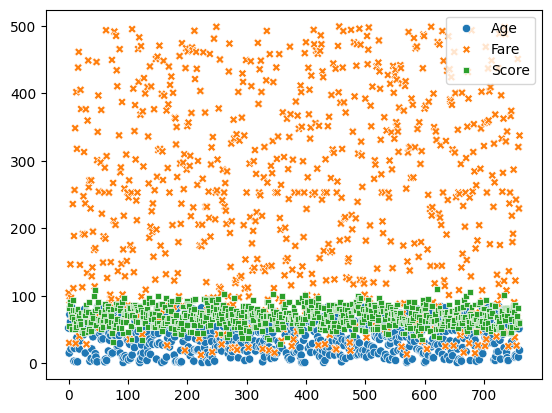

In [115]:
sns.scatterplot(data=dataset_clean[cols_to_scale])

<Axes: >

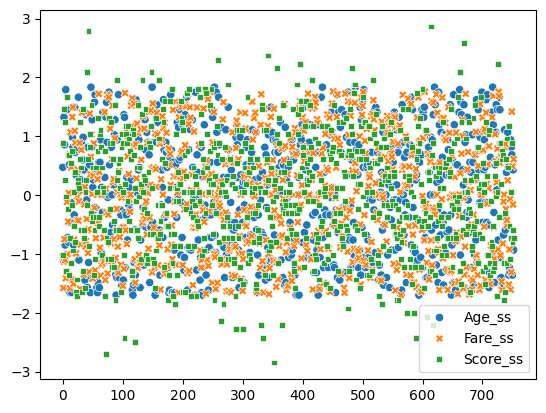

In [116]:
sns.scatterplot(data=scaled_df)

### Combining the cleaned dataset and the scaled columns

In [117]:
# 1. Reset the index of dataset_clean so it matches the scaled_df (0, 1, 2...)
dataset_clean = dataset_clean.reset_index(drop=True)

In [118]:
dataset_final = pd.concat([dataset_clean, scaled_df], axis=1)
dataset_final

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode,Age_ss,Fare_ss,Score_ss
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN,0.471379,-1.051133,-1.012194
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN,-1.104088,-1.579518,0.891322
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10,1.322983,-1.132609,1.455327
3,4,61.0,146.51,Male,London,Basic,87.0,2020-01-04,user3@example.com,+1-555-9521,Yes,Average,D04,WELCOME50,0.854601,-0.749941,1.243825
4,5,21.0,96.74,M,Tokyo,Basic,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01,NaN,-0.848607,-1.104406,0.256817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,757,60.0,67.70,male,New York,Basic,70.0,2020-12-06,user340@example.com,+1-555-2234,1,ok,D02,NaN,0.812020,-1.311230,0.045315
749,758,57.0,450.79,male,New York,Basic,82.0,2020-05-27,user147@example.com,+1-555-8248,0,ok,D03,NaN,0.684280,1.417161,0.891322
750,759,9.0,320.40,F,Paris,Premium,58.0,2020-11-26,user330@example.com,+1-555-3250,True,ok,D03,SAVE10,-1.359569,0.488515,-0.800692
751,760,51.0,229.23,male,Paris,Basic,61.0,2020-02-07,user37@example.com,+1-555-4198,Yes,Average,D04,NaN,0.428799,-0.160804,-0.589190


C:\Users\shikh\AppData\Local\Temp\ipykernel_19104\915198355.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_clean["Age"])
C:\Users\shikh\AppData\Local\Temp\ipykernel_19104\915198355.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_final["Age_ss"])


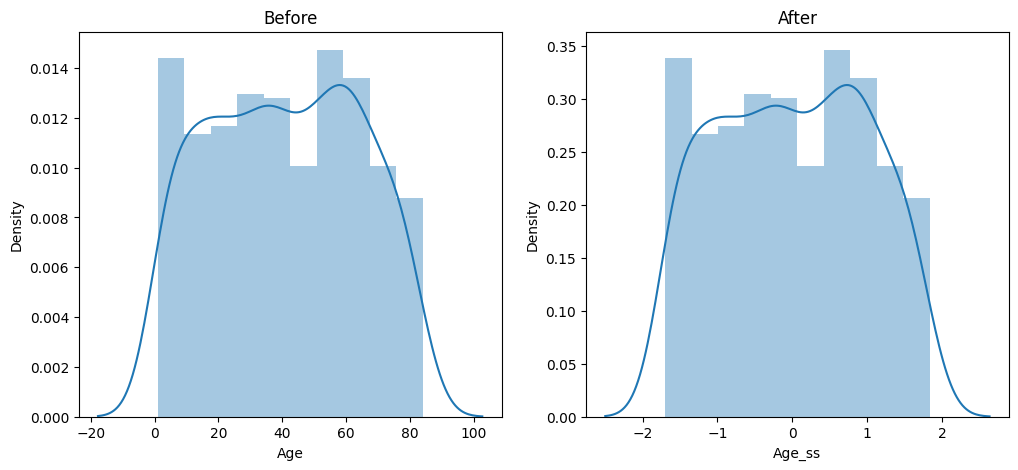

In [119]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Before")
sns.distplot(dataset_clean["Age"])
plt.subplot(1,2,2)
plt.title("After")
sns.distplot(dataset_final["Age_ss"])
plt.show()

In [120]:
# 2. Directly assign the scaled columns back
dataset_clean_scaled = dataset_clean
dataset_clean_scaled[['Age', 'Fare', 'Score']] = scaled_df
dataset_clean_scaled.head()

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,0.471379,-1.051133,F,Tokyo,Free,-1.012194,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,-1.104088,-1.579518,F,London,Premium,0.891322,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,1.322983,-1.132609,Female,New York,Basic,1.455327,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10
3,4,0.854601,-0.749941,Male,London,Basic,1.243825,2020-01-04,user3@example.com,+1-555-9521,Yes,Average,D04,WELCOME50
4,5,-0.848607,-1.104406,M,Tokyo,Basic,0.256817,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01,NaN


# Feature scaling - Normalization

# Understanding Normalization (Min-Max Scaling) 📏

While **Standardization** (which we just did) centers data around zero, **Normalization** is about "squashing" your data into a fixed, predictable range—usually **0 to 1**.

---

## 🧠 The "Rubber Band" Concept
Imagine each of your columns is a rubber band of a different length:
- **Age** is a short rubber band (0 to 100).
- **Salary** is a massive rubber band (0 to 500,000).

Normalization takes both rubber bands and stretches (or shrinks) them so they are both **exactly 10 centimeters long**. 

- The **Minimum** value in your data becomes **0**.
- The **Maximum** value in your data becomes **1**.
- Everything else is placed proportionally in between.

---

## ⚖️ When do you use Normalization instead of Standardization?

### 1. When you don't know the distribution
If your data does **not** follow a Bell Curve (Normal Distribution), Normalization is often better. It doesn't care about means or standard deviations; it only cares about the boundaries (Min and Max).

### 2. Deep Learning & Image Processing
Neural Networks almost always prefer data between 0 and 1. For example, image pixels are naturally 0 (black) to 255 (white). We "normalize" them to 0.0–1.0 so the math inside the brain of the AI stays stable.

### 3. Specific Algorithm Requirements
Models like **KNN (K-Nearest Neighbors)** and **Artificial Neural Networks** are very sensitive to the range of data. Normalization ensures that "distance" calculations are fair across all features.

---

## ⚠️ The "Outlier" Warning (Crucial!)
Normalization is **extremely weak** against outliers. 
- If you have ages 20, 30, 40 and one outlier of **1,000**:
- The 1,000 becomes **1.0**.
- The 20, 30, and 40 will all be squashed to something like **0.02, 0.03, and 0.04**.

The model can no longer "see" the difference between a 20-year-old and a 40-year-old because they are now too close together at the bottom of the scale. 

> [!IMPORTANT]
> This is why we **must** remove outliers before using a Normalization (Min-Max) scaler!

---

## 🧪 Summary: The 0-to-1 Rule
- **Standardization**: Centers data at 0 (can go negative). Best for Bell Curves.
- **Normalization**: Squashes data between 0 and 1 (always positive). Best for Neural Networks and non-Gaussian data.
